# Tutorial 1: first steps

**What you will learn**
1. how to load feynsage and ask any function what it does
2. the tadpole $A_0$ and the bubble $B_0$: their pole and their finite part
3. how to get numbers, also above a threshold where the integral is complex
4. how to make a plot of a loop function

**Before you start.** Open this notebook with the *SageMath* kernel. If you ran `./install.sh`, `from feynsage import *` works from any folder. The first cell also makes it work from this folder without installing.

All one-loop functions use the normalisation of Package-X and LoopTools,
$$\mu^{2\epsilon}e^{\epsilon\gamma_E}\int \frac{d^d\ell}{i\pi^{d/2}} \;\frac{1}{(\ell^2-m^2+i0)\cdots}, \qquad d = 4 - 2\epsilon ,$$
so the results can be compared with those programs number by number. (At one loop this is the same as the note's $(2\pi\mu)^{4-d}/(i\pi^2)$ with $1/\epsilon$ standing for $1/\epsilon - \gamma_E + \log 4\pi$.)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))     # use the feynsage of this repository (not needed after ./install.sh)
from feynsage import *
%display latex

## Step 1: ask a function what it does

Every public function carries its own explanation. `info(f)` prints it. Most functions also take `explain=True`.

In [2]:
info(A0)

A0
--
Tadpole A0(m) = m^2 (1/eps + log(mu^2/m^2) + 1) in the Package-X normalisation; A0(0) = 0.
Output: a symbolic expression in eps (the 1/eps UV pole) and mu (the renormalisation scale).


## Step 2: the tadpole $A_0(m)$

The simplest loop integral has one propagator. `var` makes a symbol in Sage.

In [3]:
m = var('m')
a = A0(m)
a

m^2*(1/eps + log(mu^2/m^2) + 1)

The result is $m^2\left(\frac{1}{\epsilon} + \log\frac{\mu^2}{m^2} + 1\right)$. The $1/\epsilon$ is the ultraviolet pole and $\mu$ is the renormalisation scale. Three small functions pull the pieces apart:
- `uv_part(x)`: the coefficient of $1/\epsilon$
- `pole_parts(x)`: the coefficients of $1/\epsilon^2$ and $1/\epsilon$
- `finite_part(x)`: the $\epsilon^0$ part (`finite_part(x, value)` also sets $\mu$ to that value)

In [4]:
print("pole:          ", uv_part(a))
print("finite part:   ", finite_part(a))
print("finite, mu = m:", finite_part(a, m))

pole:           m^2
finite part:    m^2*log(mu^2/m^2) + m^2
finite, mu = m: m^2


## Step 3: the bubble $B_0(s; m_1, m_2)$

Two propagators, $(\ell, m_1)$ and $(\ell + p, m_2)$ with $p^2 = s$.

In [5]:
s = var('s')
b = B0(s, m, m)
b

1/eps + DiscB(s, m, m) + log(mu^2/m^2) + 2

$\Lambda(s; m, m)$ is the function `DiscB`, the logarithm that carries the threshold (Package-X uses the same name),
$$\mathrm{DiscB}(s, m_1, m_2) = \frac{\sqrt{\lambda}}{s}\log\frac{m_1^2 + m_2^2 - s + \sqrt{\lambda}}{2 m_1 m_2}, \qquad \lambda = \lambda(s, m_1^2, m_2^2) .$$

**Check.** The ultraviolet pole of $B_0$ is 1 for any masses and any $s$, because at large $\ell$ the integrand is $1/\ell^4$ and does not know about masses or momenta.

In [6]:
m1, m2 = var('m1 m2')
uv_part(B0(s, m1, m2)), uv_part(B0(s, 0, 0)), uv_part(B0(0, m, m))

(1, 1, 1)

## Step 4: numbers, and the imaginary part above threshold

Put numbers in and call `.n()`. Below the threshold $s = 4m^2$ the bubble is real. Above it the two particles in the loop can be real, so the bubble picks up an imaginary part. The lecture note (Section 12) finds
$$\operatorname{Im} B_0 = \pi\beta, \qquad \beta = \sqrt{1 - 4m^2/s} .$$
Let us check this with $m = \mu = 1$.

In [7]:
for sv in [1, 3, 5, 10]:
    val = finite_part(B0(sv, 1, 1), 1).n()
    beta = sqrt(1 - 4/sv) if sv > 4 else 0
    print("s = %2d   B0 finite = %-45s   pi*beta = %.12f" % (sv, val, (pi*beta).n()))

s =  1   B0 finite = 0.186200635765782 + 2.09199576156145e-26*I      pi*beta = 0.000000000000
s =  3   B0 finite = 0.790800423843855 + 1.41839915231229e-25*I      pi*beta = 0.000000000000
s =  5   B0 finite = 1.56959105903600 + 1.40496294620815*I           pi*beta = 1.404962946208
s = 10   B0 finite = 0.401668519244090 + 2.43346720558417*I          pi*beta = 2.433467205584


Below threshold the imaginary part is zero (the tiny $10^{-26}\,i$ is rounding). Above threshold it is $\pi\beta$ to every digit.

## Step 5: a plot

`quick_plot` plots the finite part of anything with $1/\epsilon$ in it. It draws the real part as a full line and the imaginary part as a dashed line.

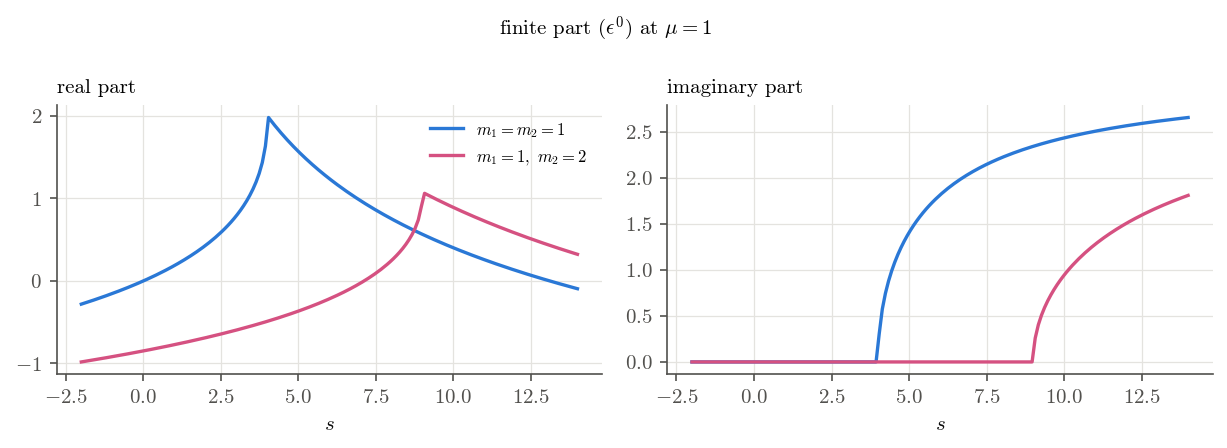

In [8]:
from feynsage.plotting import quick_plot, set_theme
set_theme()
quick_plot([B0(s, 1, 1), B0(s, 1, 2)], (s, -2, 14), labels=["$m_1 = m_2 = 1$", "$m_1 = 1,\\ m_2 = 2$"]);

The kinks are the thresholds $s = (m_1 + m_2)^2 = 4$ and $9$. The imaginary part starts there.

## Step 6: an identity between $A_0$ and $B_0$

At $s = 0$ with equal masses the bubble is the derivative of the tadpole with respect to $m^2$. In this normalisation it gives $A_0(m) = m^2\,(B_0(0; m, m) + 1)$. Sage can check it exactly.

In [9]:
(A0(m) - m^2*(B0(0, m, m) + 1)).simplify_full()

0

## Step 7: the same integrals in the notation of the lecture note

The note works in Euclidean space with the measure $[d\ell] = d^D\ell/\pi^{D/2}$ and keeps $D$ general. These closed results are in `feynsage.oneloop`:
- `tadpole(n, m2)` $= \int [d\ell]\,(\ell^2 + m^2)^{-n} = \Gamma(n - D/2)\,(m^2)^{D/2 - n}/\Gamma(n)$
- `bubble_massless(a, b, p2)`, `bubble_equal_mass(p2, m2)`, `triangle_onshell(a1, a2, a3, Q2)`

`expand_eps(expr, order, loops)` puts $D = 4 - 2\epsilon$, multiplies by $e^{L\epsilon\gamma_E}$ and expands.

In [10]:
from feynsage.oneloop import tadpole, bubble_massless, expand_eps, D
tadpole(1, 1)

gamma(-1/2*D + 1)

In [11]:
expand_eps(tadpole(1, 1), 1)

-1/12*((pi^2 + 12)*eps^2 + 12*eps + 12)/eps

The pole is $-1/\epsilon$ here and $+m^2/\epsilon$ in $A_0$. The two differ only by the Wick rotation: $d^D\ell_M = i\,d^D\ell_E$ and $\ell_M^2 - m^2 = -(\ell_E^2 + m^2)$, so the factor $1/i$ in the normalisation and one minus sign for the one propagator turn one into the other.

## Exercises

**1.** Find the finite part of the massless bubble $B_0(s; 0, 0)$ and show that for $s < 0$ it is $2 - \log(-s/\mu^2)$.
<details><summary>Show a solution</summary>

```python
s = var('s')
f = finite_part(B0(s, 0, 0))
print(f)
# LogM(z) is log(z - i0); for s < 0 its argument -s is positive, so it is the plain log
print(finite_part(B0(-3, 0, 0), 1).n(), (2 - log(3)).n())
```
</details>

**2.** Where does the imaginary part of $B_0(s; 1, 2)$ switch on? Check your answer with numbers on both sides.
<details><summary>Show a solution</summary>

```python
for sv in [8.9, 9.1]:
    print(sv, finite_part(B0(sv, 1, 2), 1).n())
# the threshold is s = (m1 + m2)^2 = 9
```
</details>

**3.** Expand the massless Euclidean bubble `bubble_massless(1, 1, 1)` and compare with the note: $1/\epsilon + 2 + O(\epsilon)$.
<details><summary>Show a solution</summary>

```python
expand_eps(bubble_massless(1, 1, 1), 0)
```
</details>